📘 **Introduction: Understanding Asthma Through Clustering – A Data-Driven Approach**


#### **Background**

Asthma is a chronic respiratory condition characterized by inflammation and narrowing of the airways, leading to episodes of wheezing, breathlessness, chest tightness, and coughing. Despite being a well-recognized condition affecting over 300 million people worldwide, the nature and triggers of asthma remain highly heterogeneous. Some individuals experience mild symptoms infrequently, while others endure persistent and severe manifestations that significantly impair their quality of life. This variability highlights a fundamental truth: asthma is not a singular disease but rather a collection of different phenotypes, each driven by different underlying mechanisms and environmental influences.

Traditional medical diagnosis of asthma tends to adopt a one-size-fits-all approach. However, this method often fails to capture the complexity of the condition, particularly in patients with atypical presentations or multiple comorbidities. Recent advances in precision medicine and data science have prompted researchers to explore more nuanced models of asthma classification. Unsupervised learning techniques such as clustering have emerged as powerful tools for uncovering hidden patterns in patient data that might otherwise go unnoticed.

In this notebook, I embark on a journey to identify distinct asthma subtypes using clustering algorithms. The dataset used in this analysis is a synthetic but realistic representation of 10,000 individuals with variome health and lifestyle attributes that may relate to asthma. Through careful preprocessing and application of clustering techniques, I aim to segment these individuals into meaningful groups and analyze the defining characteristics of each cluster. The overarching goal is to derive insights that can inform targeted interventions, personalized treatment plans, and ultimately, improved patient outcomes.

#### Problem Statement

Asthma diagnosis and treatment have long been challenged by the disease's diverse presentations. A single set of symptoms or triggers may not apply to all patients, and the clinical course of the disease often differs substantially between individuals. This poses a challenge not only for clinicians but also for public health authorities attempting to manage the disease at a population level.

This project seeks to apply unsupervised machine learning to address the following questions:

* Can I identify distinct subgroups (clusters) among individuals based on demographic, behavioral, clinical, and environmental factors?
* What are the defining characteristics of each asthma cluster?
* Can I hypothesize the underlying causes or triggers associated with each cluster?
* What specific preventive or therapeutic strategies might be appropriate for each group?

Rather than developing a predictive model, my aim is exploratory: I seek to learn from the data itself without predefined labels or classifications. This unsupervised approach is particularly valuable when dealing with complex syndromes like asthma, where labels may be insufficient, imprecise, or entirely absent.

####About the Dataset

The dataset used for this analysis contains 10,000 records with the following attributes:

* **Demographics:** Age, Gender, BMI, Smoking Status, Family History.

* **Environmental Factors:** Air Pollution Level, Occupation Type.

* **Lifestyle Indicators:** Physical Activity Level, Medication Adherence.

* **Medical History:** Allergies, Comorbidities, Number of ER Visits.

* **Clinical Measurements:** Peak Expiratory Flow, FeNO Level.

* **Asthma Status:** Has_Asthma (binary), Asthma_Control_Level (categorical – limited use due to missing values).

Each record corresponds to a unique patient identified by an anonymized Patient ID. While the data is synthetic, it is designed to reflect real-world variability and complexity.

Importantly, I emphasize that the analysis is performed without relying on the **Has_Asthma** or **Asthma_Control_Level** variables for clustering. This ensures that the clusters discovered are not biased by prior classifications but are instead based on natural groupings found within the data




#### **Significance of Clustering in Asthma Research**

Clustering, a form of unsupervised learning, is used to group similar data points together based on feature similarity. In medical research, this technique has gained popularity for its ability to reveal subgroups of patients that may not be readily apparent through conventional analysis. Such stratification is especially useful in diseases like asthma, where symptoms and causes are multifactorial and heterogeneous.

By clustering asthma patients into phenotypically distinct subgroups, I can:

* Improve my understanding of disease heterogeneity.
* Identify high-risk populations.
* Develop tailored interventions for each group.
* Enable more efficient resource allocation in public health.

Moreover, clustering offers an opportunity to explore potential asthma endotypes — subtypes defined by distinct pathophysiological mechanisms — which are increasingly being recognized in modern respiratory medicine.

#### Research Goals

The specific goals of this notebook are as follows:

1.  **Data Preprocessing:** Clean, encode, and normalize the dataset to prepare for clustering.

2.  **Feature Selection:** Choose the most relevant features that may contribute to asthma heterogeneity.

3.  **Clustering:** Apply one or more clustering algorithms (e.g., k-means, hierarchical clustering) to identify patient subgroups.

4.  **Evaluation:** Use silhouette scores and elbow plots to determine the optimal number of clusters.

5.  **Cluster Profiling:** Analyze each cluster's composition to infer likely asthma causes and patterns.

6.  **Recommendations:** Based on cluster characteristics, propose targeted strategies for asthma management and prevention.

This analysis is intended not only to demonstrate the power of unsupervised learning in healthcare but also to inspire future work in the personalization of asthma treatment.

# ⚙️ **Approach and Methodology**

#### **Overview**

The core objective of this project is to identify subgroups of individuals with distinct asthma-related characteristics using **unsupervised clustering techniques**. Our approach follows a structured data science pipeline, ensuring that each step contributes meaningfully to the discovery of clinically relevant patterns. Below is a breakdown of the methodology:

Step 1: Data Cleaning and Preprocessing

* Removed non-informative columns such as Patient_ID, Asthma_Control_Level, and Has_Asthma.
* Applied one-hot encoding to all categorical features to allow numerical analysis.
* Standardized all features using StandardScaler to ensure equal weighting.

Step 2: Feature Selection

Included:

* **Demographics:** Age, Gender, BMI, Smoking Status, Family History.

* **Environment:** Air Pollution Level, Occupation Type.

* **Lifestyle:** Physical Activity Level, Medication Adherence.

* **Medical History:** Allergies, Comorbidities, Number of ER Visits.

* **Clinical Metrics:** Peak Expiratory Flow, FeNO Level.

These are known to influence asthma and its severity.

Step 3: Clustering Algorithm Selection

I used:

* **K-Means Clustering** for its simplicity and scalability
* **Elbow Method** to determine the ideal number of clusters
* **Silhouette Score** to evaluate cluster quality

Step 4: Cluster Profiling and Interpretation

* Calculated summary statistics per cluster.

* Visualized key differences with boxplots and countplots.

* Interpreted each cluster in relation to asthma phenotypes and proposed tailored recommendations.

#### Why This Approach is Effective

* Unsupervised learning allows novel pattern discovery.

* Medical interpretability ensures clinical relevance.

* Scalable and applicable to real-world health systems.

# Import packages

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
import warnings
warnings.filterwarnings("ignore")

## 📌 2. Load Raw Dataset

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("miadul/asthma-synthetic-medical-dataset")

print("Path to dataset files:", path)

100%|██████████| 186k/186k [00:00<00:00, 64.6MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/miadul/asthma-synthetic-medical-dataset/versions/1


In [3]:
from google.colab import files

uploaded = files.upload()

Saving synthetic_asthma_dataset.csv to synthetic_asthma_dataset.csv


In [5]:
df = pd.read_csv('synthetic_asthma_dataset.csv')

df.head()

,Patient_ID,Age,Gender,BMI,Smoking_Status,Family_History,Allergies,Air_Pollution_Level,Physical_Activity_Level,Occupation_Type,Comorbidities,Medication_Adherence,Number_of_ER_Visits,Peak_Expiratory_Flow,FeNO_Level,Has_Asthma,Asthma_Control_Level
0,ASTH100000,52,Female,27.6,Former,1,NaN,Moderate,Sedentary,Outdoor,Diabetes,0.38,0,421.0,46.0,0,NaN
1,ASTH100001,15,Male,24.6,Former,0,Dust,Low,Moderate,Indoor,Both,0.60,2,297.6,22.9,0,NaN
2,ASTH100002,72,Female,17.6,Never,0,NaN,Moderate,Moderate,Indoor,NaN,0.38,0,303.3,15.3,0,NaN
3,ASTH100003,61,Male,16.8,Never,0,Multiple,High,Sedentary,Outdoor,Both,0.60,1,438.0,40.1,1,Poorly Controlled
4,ASTH100004,21,Male,30.2,Never,0,NaN,Moderate,Active,Indoor,NaN,0.82,3,535.0,27.7,0,NaN


In [6]:
# Data preprocessing
# Drop unused or identifier columns
df_cleaned = df.drop(columns=["Patient_ID", "Asthma_Control_Level", "Has_Asthma"])

# One-hot encode categorical columns
df_encoded = pd.get_dummies(df_cleaned)

# Feature scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_encoded)

print("Processed shape:", scaled_data.shape)

Processed shape: (10000, 28)


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               10000 non-null  object 
 1   Age                      10000 non-null  int64  
 2   Gender                   10000 non-null  object 
 3   BMI                      10000 non-null  float64
 4   Smoking_Status           10000 non-null  object 
 5   Family_History           10000 non-null  int64  
 6   Allergies                7064 non-null   object 
 7   Air_Pollution_Level      10000 non-null  object 
 8   Physical_Activity_Level  10000 non-null  object 
 9   Occupation_Type          10000 non-null  object 
 10  Comorbidities            5033 non-null   object 
 11  Medication_Adherence     10000 non-null  float64
 12  Number_of_ER_Visits      10000 non-null  int64  
 13  Peak_Expiratory_Flow     10000 non-null  float64
 14  FeNO_Level             

* We have 17 columns and 10000 rows in the dataset.
* In this dataset, we have 8 numerical and 9 categorical columns.
* There are 3 columns with missing values, which are Asthma_Control_Level, Comorbidities and Allergies.

In [12]:
df.describe()

,Age,BMI,Family_History,Medication_Adherence,Number_of_ER_Visits,Peak_Expiratory_Flow,FeNO_Level,Has_Asthma,Cluster
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,44.930700,25.053320,0.303400,0.497998,1.015900,400.884090,25.101420,0.243300,2.208500
std,25.653559,4.874466,0.459749,0.224809,1.020564,97.531113,9.840184,0.429096,1.407702
min,1.000000,15.000000,0.000000,0.000000,0.000000,150.000000,5.000000,0.000000,0.000000
25%,23.000000,21.600000,0.000000,0.320000,0.000000,334.800000,18.200000,0.000000,1.000000
50%,45.000000,25.000000,0.000000,0.500000,1.000000,402.500000,25.000000,0.000000,2.000000
75%,67.000000,28.400000,1.000000,0.670000,2.000000,468.700000,31.700000,0.000000,4.000000
max,89.000000,45.000000,1.000000,0.990000,6.000000,600.000000,63.900000,1.000000,4.000000


* The mean age is 44.93, std is 25.65, min is 1, and max is 89.
* The mean BMI is 25.053320, std is 4.874466, min is 15, and max is 45.
* The mean family history range is 0 to 1.
* The mean medication adherence is 0.497998, std is 0.224809, min is 0, and max is 0.99.
* The mean number of ER visits is 1.02, std is 1.02, min is 0, and max is 6.
* The mean peak expiratory flow is 400.88, std is 7.539, min is 150, and max is 600.
* The mean FeNO level is 400.88, std is 7.539, min is 150, and max is 600.
* The has asthma range is 0 to 1.

In [13]:
df.describe(include='object')

,Patient_ID,Gender,Smoking_Status,Allergies,Air_Pollution_Level,Physical_Activity_Level,Occupation_Type,Comorbidities,Asthma_Control_Level
count,10000,10000,10000,7064,10000,10000,10000,5033,2433
unique,10000,3,3,4,3,3,2,3,3
top,ASTH109983,Female,Never,Dust,Moderate,Sedentary,Indoor,Diabetes,Not Controlled
freq,1,4814,6070,2479,4915,4062,7035,2029,1229


* The gender column has 3 unique values.
* The smoking status column has 3 unique values.
* The allergies column has 4 unique values.
* The air pollution level column has 3 unique values.
* The physical activity level column has 3 unique values.
* The occupation type column has 2 unique values.
* The comorbidities column has 3 unique values.
* The asthma control level column has 3 unique values.

### Check the Unique Values in all categorical columns in the dataset

> Agregar bloque entrecomillado



In [14]:
# Make function check all object column value counts

def check_obj_col(df):
    for col in df.select_dtypes('object').columns:
        if col == 'Patient_ID':
            continue
        print(df[col].value_counts())
        print('\n')

check_obj_col(df)

Gender
Female    4814
Male      4786
Other      400
Name: count, dtype: int64


Smoking_Status
Never      6070
Former     2487
Current    1443
Name: count, dtype: int64


Allergies
Dust        2479
Pollen      1999
Pets        1585
Multiple    1001
Name: count, dtype: int64


Air_Pollution_Level
Moderate    4915
Low         2984
High        2101
Name: count, dtype: int64


Physical_Activity_Level
Sedentary    4062
Moderate     3909
Active       2029
Name: count, dtype: int64


Occupation_Type
Indoor     7035
Outdoor    2965
Name: count, dtype: int64


Comorbidities
Diabetes        2029
Hypertension    2018
Both             986
Name: count, dtype: int64


Asthma_Control_Level
Not Controlled       1229
Poorly Controlled    1120
Well Controlled        84
Name: count, dtype: int64




### 🔍 Missing Values

In [15]:
df.isnull().sum().sort_values(ascending=False).head(4)

,0
Asthma_Control_Level,7567
Comorbidities,4967
Allergies,2936
Patient_ID,0


In [16]:
(df.isnull().sum().sort_values(ascending=False) / len(df) * 100).head(4)

,0
Asthma_Control_Level,75.67
Comorbidities,49.67
Allergies,29.36
Patient_ID,0.00


In [17]:
print(df[df['Has_Asthma'] == 1]['Asthma_Control_Level'].value_counts())
df[df['Has_Asthma'] == 0]['Asthma_Control_Level'].value_counts()

Asthma_Control_Level
Not Controlled       1229
Poorly Controlled    1120
Well Controlled        84
Name: count, dtype: int64


,count
Asthma_Control_Level,


* I found high relation between Has_Asthma and Asthma_Control_Level.
* Asthma_Control_Level has 7567 missings values in the dataset.
* Similarly, 7567 No disorder in Has_Asthma column.

In [18]:
df['Asthma_Control_Level'] = df['Asthma_Control_Level'].fillna("Not Asthma")
df['Comorbidities'] = df['Comorbidities'].fillna("Unknown")
df['Allergies'] = df['Allergies'].fillna("Unknown")

### Drop the Patient_ID column

In [19]:
df.drop('Patient_ID', axis=1, inplace=True)

## 👥 Age Distribution

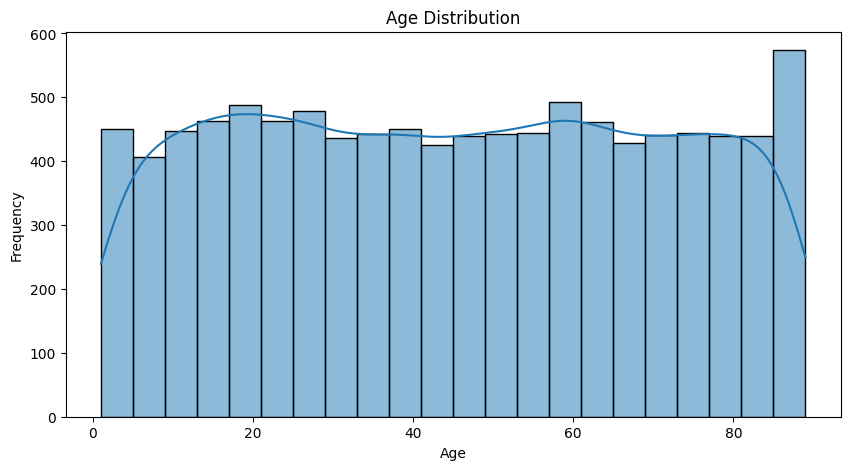

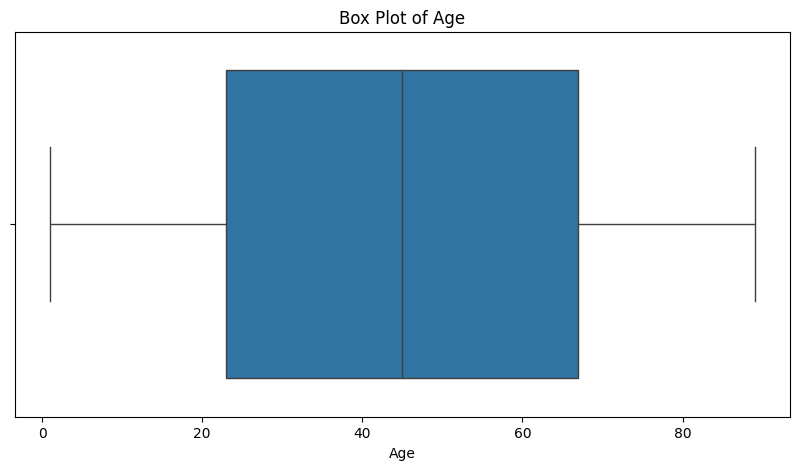

In [20]:
# Histogram
plt.figure(figsize=(10, 5))
sns.histplot(df['Age'],  kde=True)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# Box Plot
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['Age'])
plt.title('Box Plot of Age')
plt.xlabel('Age')
plt.show()

* Age column is Uniformly distributed.
* Count of every age braket is same, like 400 to 500.

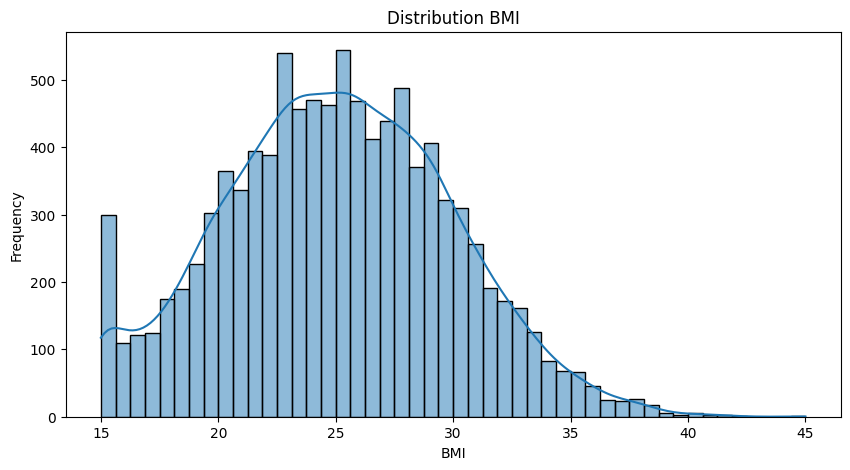

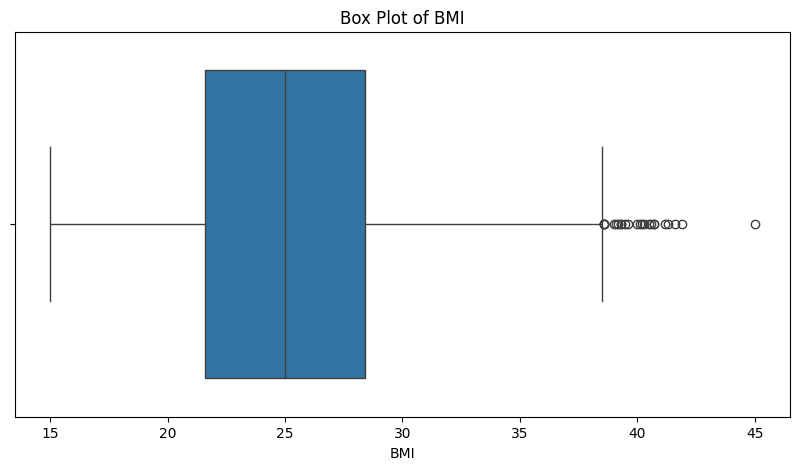

In [21]:
# Histogram
plt.figure(figsize=(10, 5))
sns.histplot(df['BMI'],  kde=True)
plt.title('Distribution BMI')
plt.xlabel('BMI')
plt.ylabel('Frequency')
plt.show()

# Box Plot
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['BMI'])
plt.title('Box Plot of BMI')
plt.xlabel('BMI')
plt.show()

* In BMI column have some outliers.
* Grater than 40 is probablity outliers.

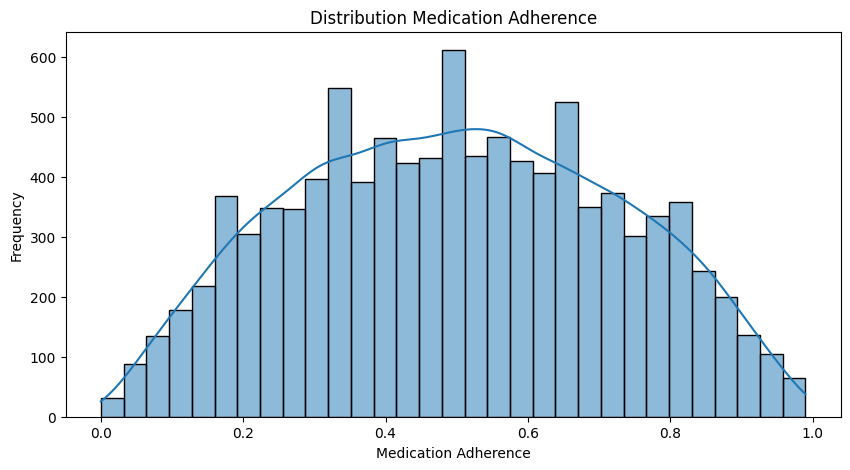

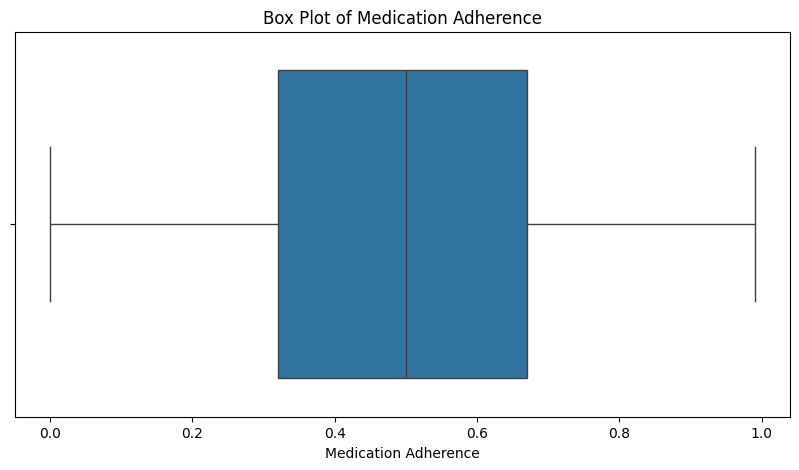

In [22]:
# Histogram
plt.figure(figsize=(10, 5))
sns.histplot(df['Medication_Adherence'],  kde=True)
plt.title('Distribution Medication Adherence')
plt.xlabel('Medication Adherence')
plt.ylabel('Frequency')
plt.show()

# Box Plot
plt.figure(figsize=(10, 5))
sns.boxplot(x=df['Medication_Adherence'])
plt.title('Box Plot of Medication Adherence')
plt.xlabel('Medication Adherence')
plt.show()

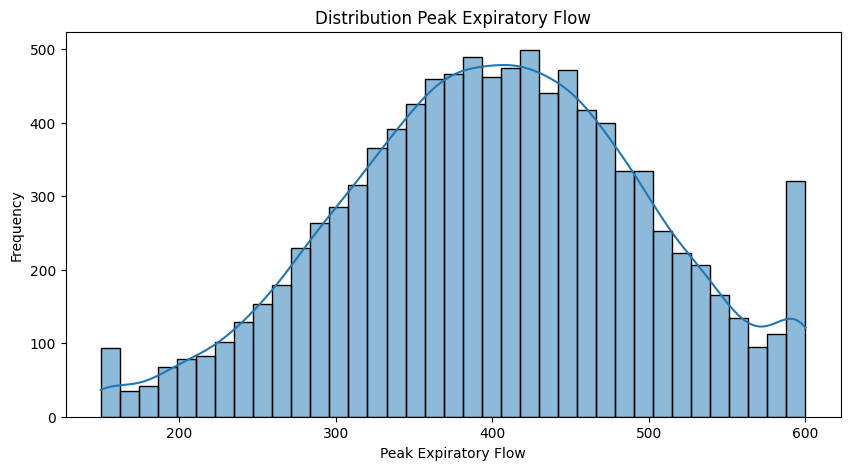

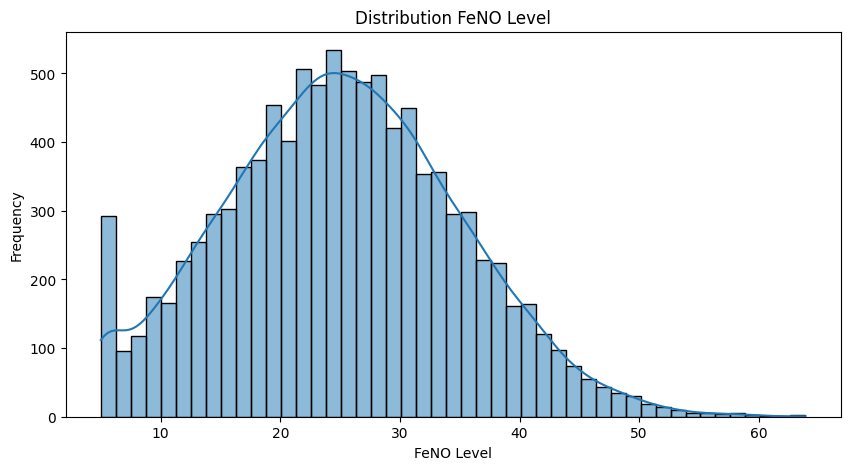

In [23]:
# Histogram
plt.figure(figsize=(10, 5))
sns.histplot(df['Peak_Expiratory_Flow'],  kde=True)
plt.title('Distribution Peak Expiratory Flow')
plt.xlabel('Peak Expiratory Flow')
plt.ylabel('Frequency')
plt.show()

# Histogram
plt.figure(figsize=(10, 5))
sns.histplot(df['FeNO_Level'],  kde=True)
plt.title('Distribution FeNO Level')
plt.xlabel('FeNO Level')
plt.ylabel('Frequency')
plt.show()

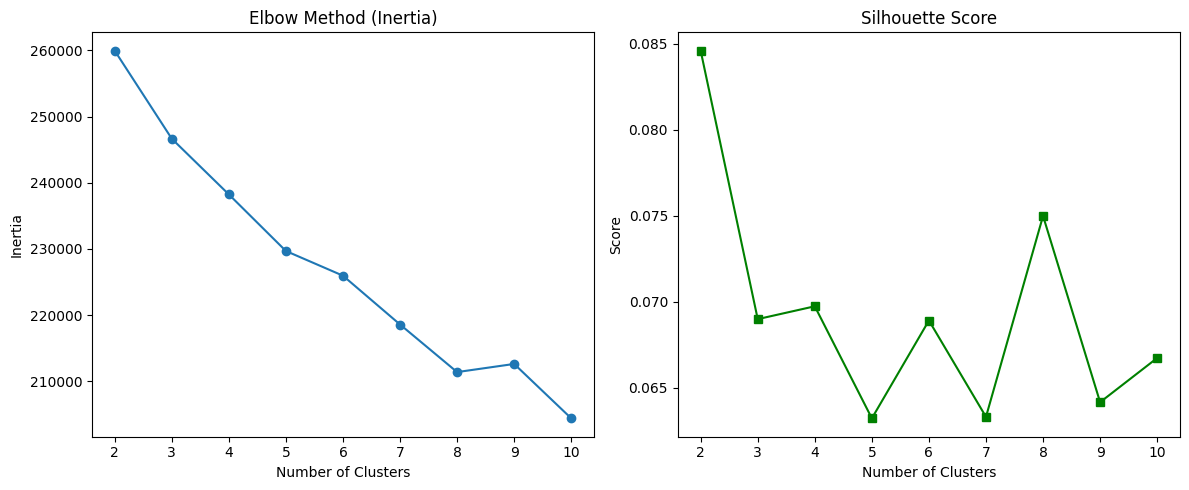

In [7]:
# 📌 4. Elbow method and silhouette score
inertia = []
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(scaled_data, kmeans.labels_))

# 📈 Plot elbow and silhouette score
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(2, 11), inertia, marker='o')
plt.title("Elbow Method (Inertia)")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")

plt.subplot(1, 2, 2)
plt.plot(range(2, 11), silhouette_scores, marker='s', color='green')
plt.title("Silhouette Score")
plt.xlabel("Number of Clusters")
plt.ylabel("Score")

plt.tight_layout()
plt.show()

In [8]:
# 📌 5. Final clustering with k=5
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(scaled_data)

# 📊 6. Cluster summary statistics
cluster_summary = df.groupby("Cluster").mean(numeric_only=True)
display(cluster_summary)

,Age,BMI,Family_History,Medication_Adherence,Number_of_ER_Visits,Peak_Expiratory_Flow,FeNO_Level,Has_Asthma
Cluster,,,,,,,,
0,45.535690,24.857866,0.292446,0.507062,1.015939,401.639432,25.472072,0.561331
1,45.077904,25.111754,0.305695,0.489358,1.026424,401.953895,24.984601,0.197722
2,44.336944,24.989396,0.297605,0.501534,1.038769,398.019783,25.077594,0.185291
3,44.665366,25.202049,0.305366,0.489215,0.997561,399.338732,24.932878,0.184878
4,45.082877,25.038077,0.310008,0.504914,1.005864,402.742494,25.143980,0.189601


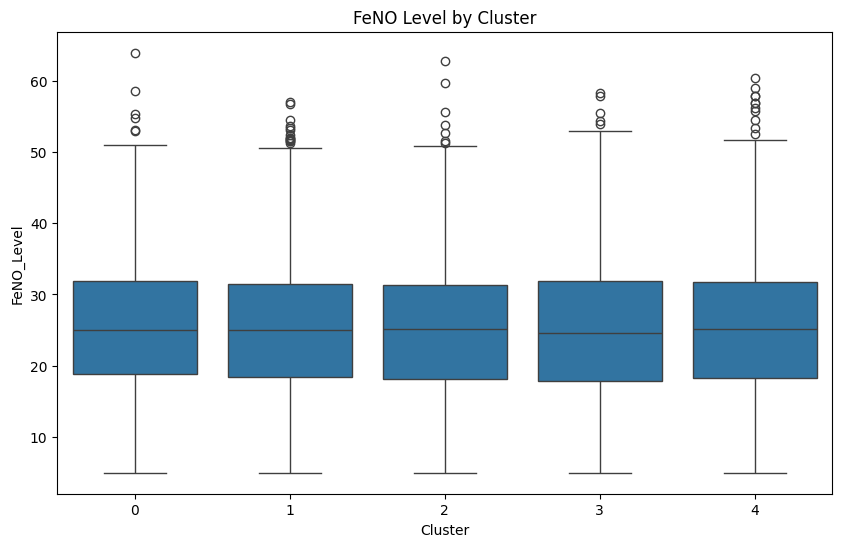

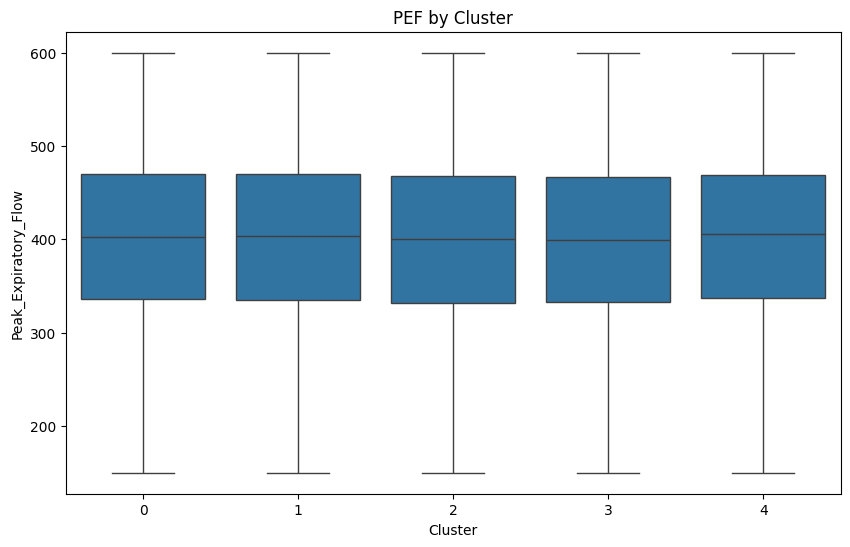

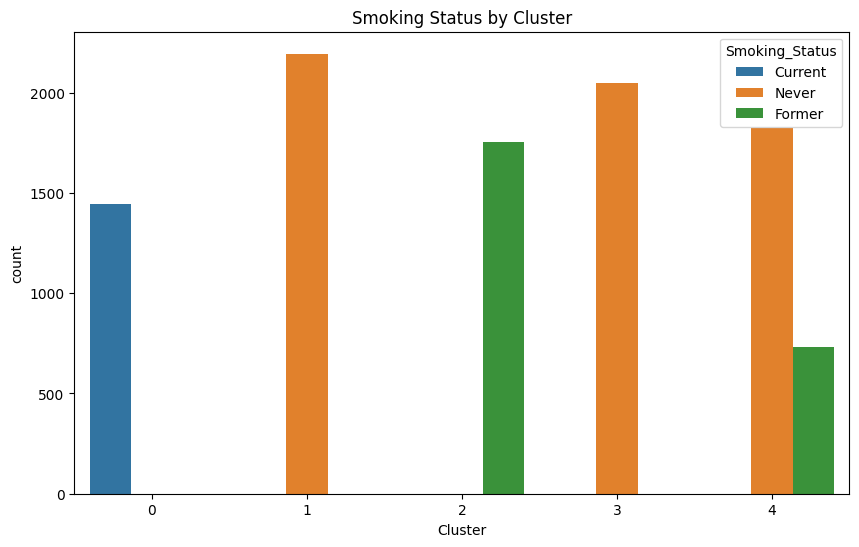

In [9]:
# 📌 7. Visualizations
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cluster', y='FeNO_Level', data=df)
plt.title("FeNO Level by Cluster")
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(x='Cluster', y='Peak_Expiratory_Flow', data=df)
plt.title("PEF by Cluster")
plt.show()

plt.figure(figsize=(10, 6))
sns.countplot(x='Cluster', hue='Smoking_Status', data=df)
plt.title("Smoking Status by Cluster")
plt.show()

# 🎯 Asthma Synthetic Dataset EDA

# Create plots for All categorical columns

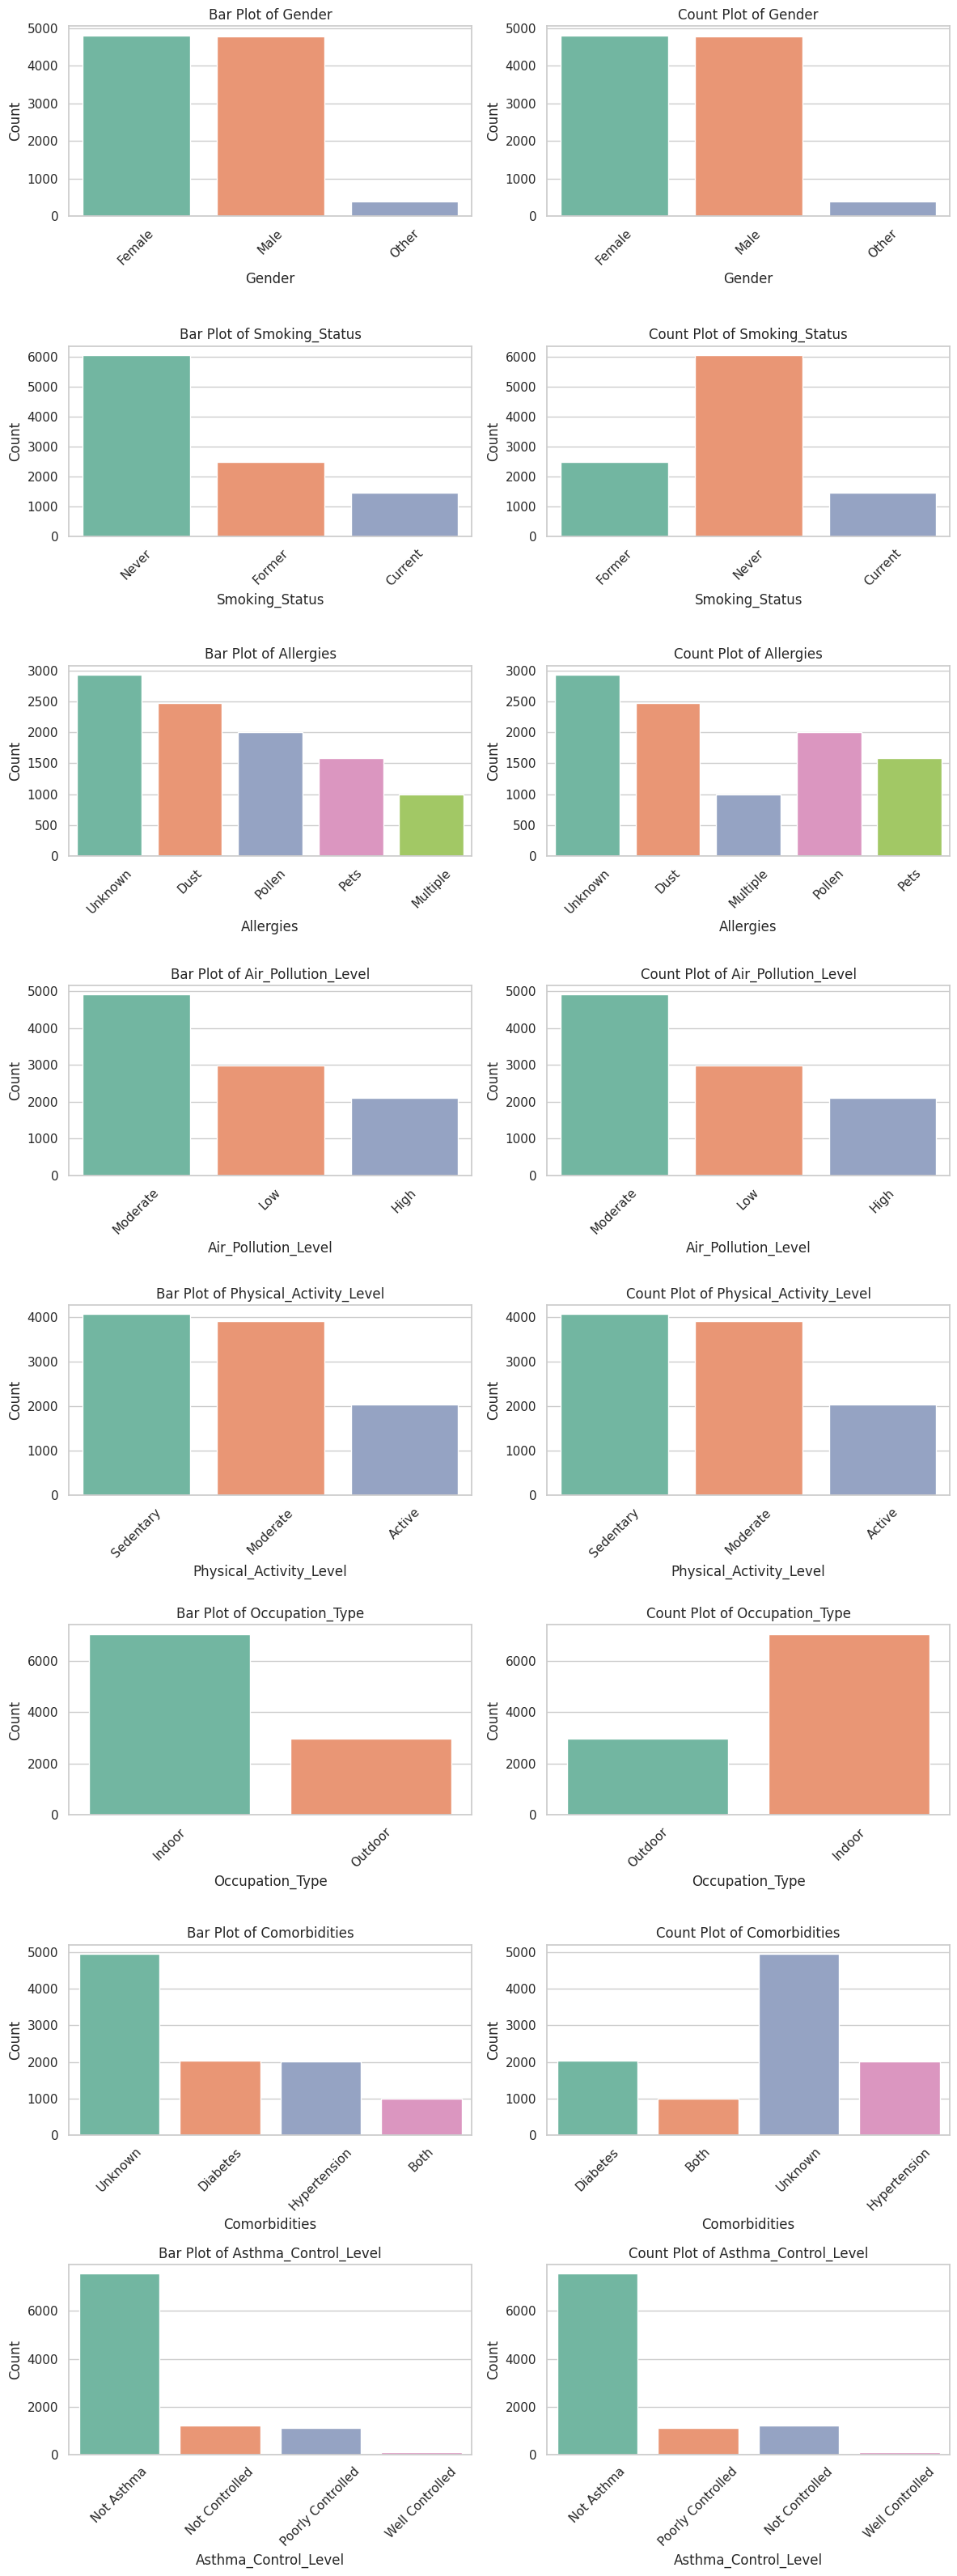

In [24]:
# List of categorical columns
categorical_columns = ['Gender', 'Smoking_Status', 'Allergies', 'Air_Pollution_Level', 'Physical_Activity_Level', 'Occupation_Type', 'Comorbidities', 'Asthma_Control_Level']

# Set the style for the plots
sns.set(style="whitegrid")

# Create a figure for subplots
fig, axes = plt.subplots(nrows=len(categorical_columns), ncols=2, figsize=(12, 4 * len(categorical_columns)))

# Loop through each categorical column to create bar and count plots
for i, column in enumerate(categorical_columns):
    # Bar Plot
    sns.barplot(x=df[column].value_counts().index, y=df[column].value_counts().values, ax=axes[i, 0], palette='Set2')
    axes[i, 0].set_title(f'Bar Plot of {column}')
    axes[i, 0].set_xlabel(column)
    axes[i, 0].set_ylabel('Count')
    axes[i, 0].tick_params(axis='x', rotation=45)

    # Count Plot
    sns.countplot(x=column, data=df, ax=axes[i, 1], palette='Set2')
    axes[i, 1].set_title(f'Count Plot of {column}')
    axes[i, 1].set_xlabel(column)
    axes[i, 1].set_ylabel('Count')
    axes[i, 1].tick_params(axis='x', rotation=45)

# Adjust layout
plt.tight_layout()
plt.show()

### Q1. Which Gender is more suffering from Asthma?

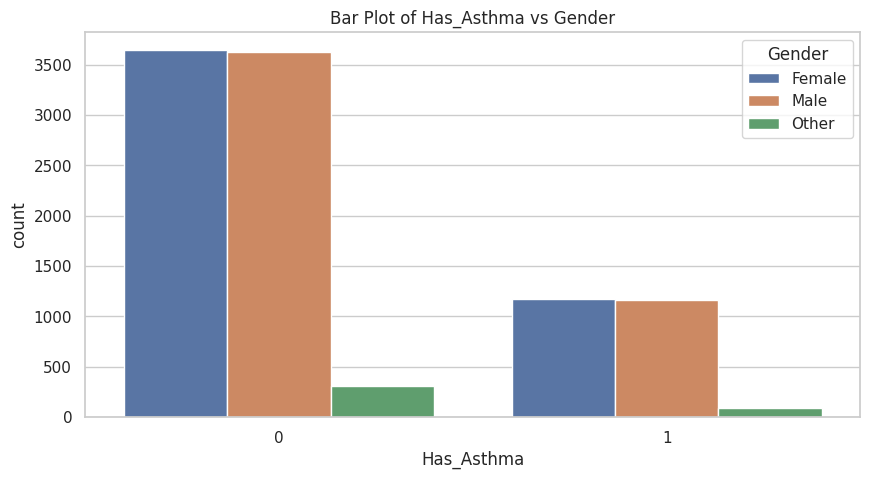

In [25]:
plt.figure(figsize=(10, 5))
plt.title('Bar Plot of Has_Asthma vs Gender')
sns.countplot(x='Has_Asthma', hue='Gender', data=df)
plt.xlabel('Has_Asthma')
plt.ylabel('count')
plt.show()

In [26]:
# how many males, female and others are suffering from asthma
df.groupby("Has_Asthma")["Gender"].value_counts()

Has_Asthma  Gender
0           Female    3641
            Male      3620
            Other      306
1           Female    1173
            Male      1166
            Other       94
Name: count, dtype: int64

* According to this dataset Female is more sufferding from Asthma.

###Q2. Can smoking cause of Asthma?

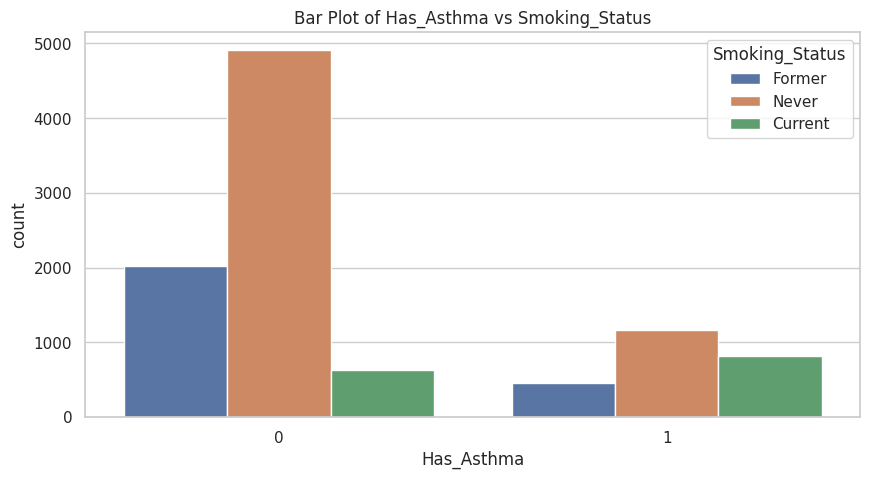

In [27]:
# Can smoking cause of asthma?
plt.figure(figsize=(10, 5))
plt.title('Bar Plot of Has_Asthma vs Smoking_Status')
sns.countplot(x='Has_Asthma', hue='Smoking_Status', data=df)
plt.xlabel('Has_Asthma')
plt.ylabel('count')
plt.show()

In [28]:
df.groupby("Has_Asthma")["Smoking_Status"].value_counts()

Has_Asthma  Smoking_Status
0           Never             4908
            Former            2026
            Current            633
1           Never             1162
            Current            810
            Former             461
Name: count, dtype: int64

* According to this dataset 1162 people are not smoking but they are suffering from Asthma, 810 asthma patient are smoking and 491 Former.
* According to this dataset 2026 people are smoking and 633 current smoking people are not suffering from Asthma.

In [29]:
# Can smoking cause of asthma use smoking status and asthma control level use groupby function
df.groupby("Smoking_Status")["Asthma_Control_Level"].value_counts()

Smoking_Status  Asthma_Control_Level
Current         Not Asthma               633
                Poorly Controlled        393
                Not Controlled           390
                Well Controlled           27
Former          Not Asthma              2026
                Not Controlled           226
                Poorly Controlled        220
                Well Controlled           15
Never           Not Asthma              4908
                Not Controlled           613
                Poorly Controlled        507
                Well Controlled           42
Name: count, dtype: int64

* According to this dataset 2433 people are suffering from Asthma.

* Current 'active' smoker 810 people are suffering from Asthma.

* Former smoker 461 people are suffering from Asthma, Total 1271 patient effected by smoking.

* Never smoker 1162 people are suffering from Asthma. Total 1162 patient effected by non-smoking.

###Q3. Can someone in the family develop asthma because of asthma?

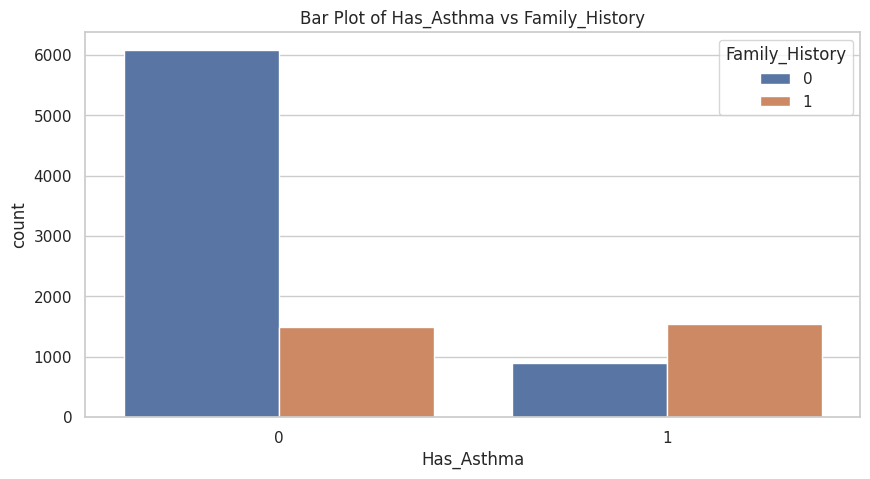

In [30]:
# Can someone in the family develop asthma because of asthma?
plt.figure(figsize=(10, 5))
plt.title('Bar Plot of Has_Asthma vs Family_History')
sns.countplot(x='Has_Asthma', hue='Family_History', data=df)
plt.xlabel('Has_Asthma')
plt.ylabel('count')
plt.show()

* Yes according to this dataset people with family history are suffering from Asthma.

### Q4. Which allergy affects asthma the most?

In [31]:
df[df['Has_Asthma'] == 1]['Allergies'].value_counts()

,count
Allergies,
Dust,767
Pollen,644
Pets,508
Multiple,328
Unknown,186


* According to this dataset 767 people are suffering from Asthma and they have dust aller

### Q5. What is the average BMI of individuals with asthma?

In [32]:
# Calculate the average BMI of individuals with asthma
average_bmi_asthma = df[df['Has_Asthma'] == 1]['BMI'].mean()

# Print the result
print("The average BMI of individuals with asthma is:", average_bmi_asthma)

The average BMI of individuals with asthma is: 25.899383477188653


* The average BMI of individuals with asthma is: 25.899

### Q6. How does age correlate with asthma control levels?

In [33]:
# Calculate the average age for each asthma control level
average_age_by_control = df.groupby('Asthma_Control_Level')['Age'].mean().reset_index()

# Print the results
print(average_age_by_control)

  Asthma_Control_Level        Age
0           Not Asthma  44.993921
1       Not Controlled  44.984540
2    Poorly Controlled  44.541964
3      Well Controlled  43.630952


###Q7. Is there a significant difference in the number of ER visits between smokers and non-smokers?

In [34]:
# Calculate the average number of ER visits for each smoking status
average_er_visits = df.groupby('Smoking_Status')['Number_of_ER_Visits'].mean().reset_index()

# Print the results
print(average_er_visits)

  Smoking_Status  Number_of_ER_Visits
0        Current             1.015939
1         Former             1.017692
2          Never             1.015157


In [35]:
df.groupby("Has_Asthma")["Number_of_ER_Visits"].value_counts()

Has_Asthma  Number_of_ER_Visits
0           1                      2771
            0                      2770
            2                      1386
            3                       476
            4                       131
            5                        31
            6                         2
1           0                       895
            1                       880
            2                       427
            3                       178
            4                        37
            5                        15
            6                         1
Name: count, dtype: int64

###Q8. What is the most common occupation type among individuals suffering from asthma?

In [36]:
# Count occurrences of each occupation type for individuals with asthma
occupation_counts = df[df['Has_Asthma'] == 1]['Occupation_Type'].value_counts()

# Get the most common occupation type
most_common_occupation = occupation_counts.idxmax()
most_common_count = occupation_counts.max()

# Print the result
print(f"The most common occupation type among individuals suffering from asthma is '{most_common_occupation}' with {most_common_count} occurrences.")

The most common occupation type among individuals suffering from asthma is 'Indoor' with 1733 occurrences.


* According to this dataset the most common occupation type among individuals suffering from asthma is 'Indoor' with 1733 occurrences.

###Q9 How does medication adherence affect asthma control levels?

In [37]:
# Calculate the average medication adherence for each asthma control level
average_adherence = df.groupby('Asthma_Control_Level')['Medication_Adherence'].mean().reset_index()

# Print the results
print(average_adherence)

  Asthma_Control_Level  Medication_Adherence
0           Not Asthma              0.497516
1       Not Controlled              0.313458
2    Poorly Controlled              0.675393
3      Well Controlled              0.876190


###Q10. Which age group has the highest prevalence of asthma?

In [38]:
# Define age brackets
bins = [0, 18, 35, 50, 100]  # Age brackets
labels = ['0-18', '19-35', '36-50', '51+']  # Labels for age groups

# Create a new column for age group
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

# Count the number of individuals with asthma in each age group
asthma_prevalence = df[df['Has_Asthma'] == 1]['Age_Group'].value_counts()

# Get the age group with the highest prevalence
most_common_group = asthma_prevalence.idxmax()
most_common_count = asthma_prevalence.max()

# Print the result
print(f"The age group with the highest prevalence of asthma is '{most_common_group}' with {most_common_count} occurrences.")

The age group with the highest prevalence of asthma is '51+' with 1076 occurrences.


* According to this dataset the age group with the highest prevalence of asthma is '51+' with 1076 occurrences.

##Machine Learning Model

* Preprocessing for the dataset use for Machine Learning Model

In [39]:
# select categorical columns
labelencoder = LabelEncoder()
categorical_columns = df.select_dtypes(include=['object']).columns
for col in categorical_columns:
    df[col] = labelencoder.fit_transform(df[col])

# Drop Age_Group column
df.drop('Age_Group', axis=1, inplace=True)

# Age, BMI, Peak_Expiratory_Flow and FeNO_Level scale the columns
scaler = MinMaxScaler()
df[['Age', 'BMI', 'Peak_Expiratory_Flow', 'FeNO_Level']] = scaler.fit_transform(df[['Age', 'BMI', 'Peak_Expiratory_Flow', 'FeNO_Level']])

* Drop the 2 main columns which are Has_Asthma and Asthma_Control_Level becuase Asthma_Control_Level is high correlated on Has_Asthma

In [40]:
# split the dataset into training and testing sets
X = df.drop(['Has_Asthma', 'Asthma_Control_Level'], axis=1)
y = df['Has_Asthma']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# train a random forest classifier
rfc = RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(X_train, y_train)

# make predictions on the test set
y_pred = rfc.predict(X_test)

# calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.999
